In [2]:
#Project Overview
#The objective of this project is to predict house rent using a deep learning approach.
#Accurate rent prediction helps tenants, landlords, and real estate platforms make
#informed decisions. The project uses a neural network regression model to learn
#complex relationships between property features and rental prices.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


In [4]:
df = pd.read_csv("melb_data.csv")
df

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.79960,144.99840,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.80790,144.99340,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.80930,144.99440,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.79690,144.99690,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.80720,144.99410,Northern Metropolitan,4019.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13575,Wheelers Hill,12 Strada Cr,4,h,1245000.0,S,Barry,26/08/2017,16.7,3150.0,...,2.0,2.0,652.0,NaN,1981.0,NaN,-37.90562,145.16761,South-Eastern Metropolitan,7392.0
13576,Williamstown,77 Merrett Dr,3,h,1031000.0,SP,Williams,26/08/2017,6.8,3016.0,...,2.0,2.0,333.0,133.0,1995.0,NaN,-37.85927,144.87904,Western Metropolitan,6380.0
13577,Williamstown,83 Power St,3,h,1170000.0,S,Raine,26/08/2017,6.8,3016.0,...,2.0,4.0,436.0,NaN,1997.0,NaN,-37.85274,144.88738,Western Metropolitan,6380.0
13578,Williamstown,96 Verdon St,4,h,2500000.0,PI,Sweeney,26/08/2017,6.8,3016.0,...,1.0,5.0,866.0,157.0,1920.0,NaN,-37.85908,144.89299,Western Metropolitan,6380.0


In [5]:
# Drop unnecessary columns if present
cols_to_drop = ['Posted On', 'Area Locality', 'Point of Contact']
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)

# Check missing values
df.isnull().sum()




,0
Suburb,0
Address,0
Rooms,0
Type,0
Price,0
Method,0
SellerG,0
Date,0
Distance,0
Postcode,0


In [6]:
# Drop missing values
df.dropna(inplace=True)


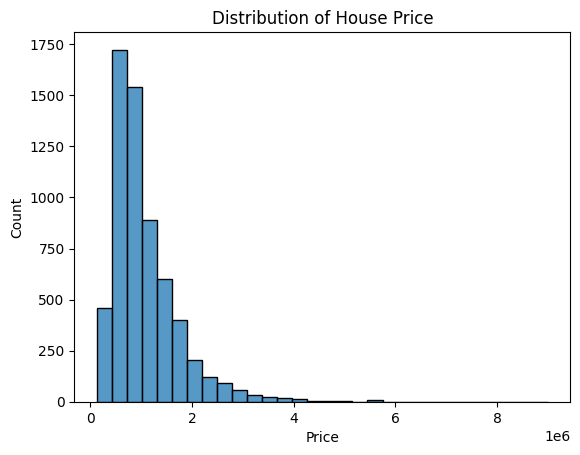

In [12]:
 #Exploratory Data Analysis (EDA)
 #Graph 1: Price Distribution
plt.figure()
sns.histplot(df['Price'], bins=30)
plt.title("Distribution of House Price")
plt.show()

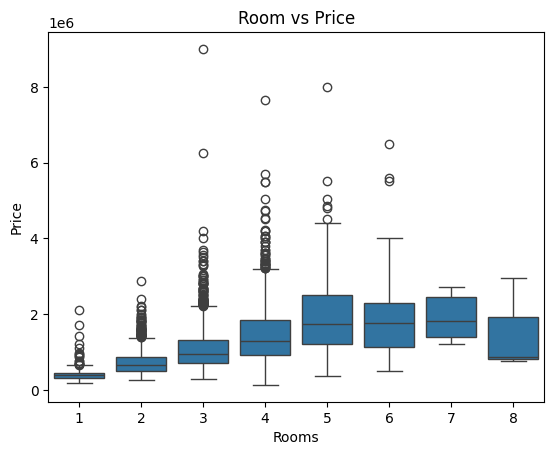

In [13]:
#.2 Graph Rooms vs Price
plt.figure()
sns.boxplot(x='Rooms', y='Price', data=df)
plt.title("Room vs Price")
plt.show()


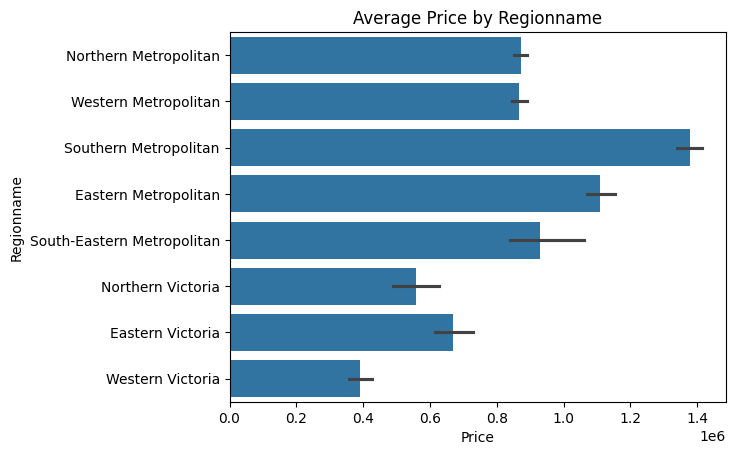

In [18]:
#Graph 3: Rent vs City
plt.figure()
sns.barplot(x='Price', y='Regionname', data=df)
plt.title("Average Price by Regionname")
plt.show()

In [19]:
# Encoding Categorical Variables
le = LabelEncoder()
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [21]:
#Feature Scalling
X = df.drop('Price', axis=1)
y = df['Price']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


In [23]:
model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,457 (13.50 KB)

 Trainable params: 3,457 (13.50 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
# Model Training
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


Epoch 1/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1541338300416.0000 - val_loss: 1734832160768.0000
Epoch 2/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1517379780608.0000 - val_loss: 1733993693184.0000
Epoch 3/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1609317875712.0000 - val_loss: 1731422584832.0000
Epoch 4/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1655353507840.0000 - val_loss: 1726127013888.0000
Epoch 5/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1575822426112.0000 - val_loss: 1717065875456.0000
Epoch 6/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1551309733888.0000 - val_loss: 1703499268096.0000
Epoch 7/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1589765210112.0000 - val_loss: 1685240545280.0000
Epoch 8/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1636918755328.0000 - val_loss: 1661494493184.0000
Epoch 9/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1479991492608.0000 - val_loss: 1632416563200.0000
Epoch 10/5

In [25]:
# Model Evaluation
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R2 Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)


39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
R2 Score: 0.34495002331109936
MAE: 406467.9046639719
RMSE: 521797.67386312713


In [26]:
from tensorflow.keras.layers import BatchNormalization


In [29]:

#ANN Batch Normalization

model_dl2 = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dense(32, activation='relu'),
    Dense(1)
])

model_dl2.compile(
    optimizer='adam',
    loss='mse'
)

model_dl2.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 128)            │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,825 (54.00 KB)

 Trainable params: 13,441 (52.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:

#Three deep learning architectures were evaluated for house price prediction.
#The ANN with Batch Normalization achieved the highest R² score, indicating better
#generalization and stable training. Dropout effectively reduced overfitting while
#the deep ANN captured  feature interactions.
